In [1]:
import os
import numpy as np
import pandas as pd

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from src.audio import extract_logmel
from src.models import MultiModalVAE, multimodal_vae_loss
from src.evaluation import evaluation_medium
from src.visualisation import plot_training_loss, plot_tsne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('results_medium/plots', exist_ok=True)

In [2]:
TSV_PATH = 'data/sampled.tsv'
AUDIO_DIR = 'data/songs'

audio_X, lyrics, genres, languages = extract_logmel(TSV_PATH, AUDIO_DIR)

  0%|          | 0/1000 [00:00<?, ?it/s]/home/tanzim/miniconda3/envs/cse715-project/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1000/1000 [01:33<00:00, 10.71it/s]


In [3]:
# Vectorise lyrics
vectorizer = TfidfVectorizer(max_features=1000)
lyrics_X = vectorizer.fit_transform(lyrics).toarray()

# Normalise
scaler_text = StandardScaler()
lyrics_X = scaler_text.fit_transform(lyrics_X)

In [4]:
# Normalise spectrogram
audio_X = (audio_X - np.mean(audio_X, axis=(1,2), keepdims=True)) / \
          (np.std(audio_X, axis=(1,2), keepdims=True) + 1e-8)

# Add channel dimension for CNN
audio_X = np.expand_dims(audio_X, axis=1)

# Convert to tensors
audio_tensor = torch.tensor(audio_X, dtype=torch.float32)
lyrics_tensor = torch.tensor(lyrics_X, dtype=torch.float32)

In [5]:
LATENT_DIM = 32
EPOCHS = 50

# Text input dimension for model
text_dim = lyrics_X.shape[1]

# Construct model and use Adam optimiser with learning rate = 1e-3
model = MultiModalVAE(text_dim, latent_dim=LATENT_DIM).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

dataset = torch.utils.data.TensorDataset(audio_tensor, lyrics_tensor)
loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

loss_history = []

for epoch in range(EPOCHS):
    total_loss = 0

    for (audio, text) in loader:
        audio = audio.to(device)
        text = text.to(device)

        optimiser.zero_grad()

        audio_recon, text_recon, mu, logvar = model(audio, text)

        loss = multimodal_vae_loss(audio_recon, audio, text_recon, text, mu, logvar)

        loss.backward()
        optimiser.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

# Save model and loss history
torch.save(model.state_dict(), 'results_medium/conv_vae.pth')
np.save('results_medium/loss_history.npy', loss_history)

Epoch 1, Loss: 1.8932
Epoch 2, Loss: 1.4983
Epoch 3, Loss: 1.3920
Epoch 4, Loss: 1.3751
Epoch 5, Loss: 1.3731
Epoch 6, Loss: 1.3708
Epoch 7, Loss: 1.3671
Epoch 8, Loss: 1.3677
Epoch 9, Loss: 1.3617
Epoch 10, Loss: 1.3656
Epoch 11, Loss: 1.3638
Epoch 12, Loss: 1.3629
Epoch 13, Loss: 1.3627
Epoch 14, Loss: 1.3610
Epoch 15, Loss: 1.3620
Epoch 16, Loss: 1.3603
Epoch 17, Loss: 1.3609
Epoch 18, Loss: 1.3597
Epoch 19, Loss: 1.3599
Epoch 20, Loss: 1.3598
Epoch 21, Loss: 1.3603
Epoch 22, Loss: 1.3603
Epoch 23, Loss: 1.3576
Epoch 24, Loss: 1.3581
Epoch 25, Loss: 1.3580
Epoch 26, Loss: 1.3578
Epoch 27, Loss: 1.3581
Epoch 28, Loss: 1.3583
Epoch 29, Loss: 1.3579
Epoch 30, Loss: 1.3588
Epoch 31, Loss: 1.3576
Epoch 32, Loss: 1.3573
Epoch 33, Loss: 1.3594
Epoch 34, Loss: 1.3568
Epoch 35, Loss: 1.3581
Epoch 36, Loss: 1.3575
Epoch 37, Loss: 1.3575
Epoch 38, Loss: 1.3579
Epoch 39, Loss: 1.3570
Epoch 40, Loss: 1.3554
Epoch 41, Loss: 1.3588
Epoch 42, Loss: 1.3585
Epoch 43, Loss: 1.3574
Epoch 44, Loss: 1.35

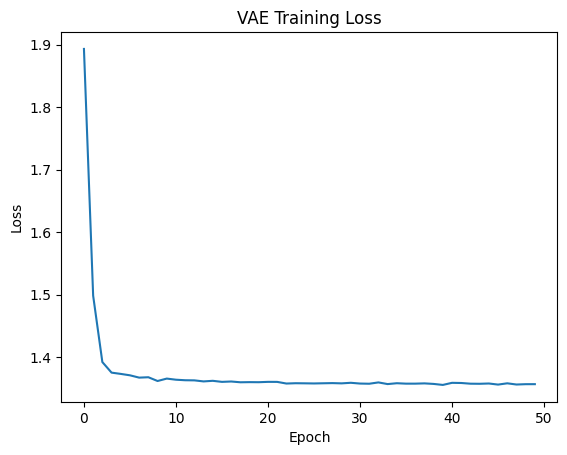

In [6]:
# Plot training loss and save figure
plot_training_loss(loss_history, 'results_medium/plots/loss_curve.svg')

In [7]:
# Get model outputs for evaluation
model.eval()
with torch.no_grad():
    mu_a, _ = model.encode_audio(audio_tensor.to(device))
    mu_t, _ = model.encode_text(lyrics_tensor.to(device))

    # Simply take mean of audio and text
    Z = ((mu_a + mu_t) / 2).cpu().numpy()

In [8]:
# Flatten audio spectrograms for PCA
audio_flat = audio_X.reshape(audio_X.shape[0], -1)

# Normalize audio before PCA
audio_flat_scaled = StandardScaler().fit_transform(audio_flat)

# Raw combined for baseline comparison
Z_raw_combined = np.concatenate([audio_flat_scaled, lyrics_X], axis=1)

# PCA
pca = PCA(n_components=LATENT_DIM, random_state=27)
Z_pca_combined = pca.fit_transform(Z_raw_combined)

In [9]:
results = []

for k, label_type, labels in [
    (2, 'language', languages),
    (6, 'genre', genres)
]:
    # Text only features
    (
        _, _, _, _,
        sil_kmeans_text, ch_kmeans_text, d_kmeans_text, ari_kmeans_text,
        sil_agglo_text, ch_agglo_text, d_agglo_text, ari_agglo_text,
    ) = evaluation_medium(lyrics_X, labels, k)

    # Raw features
    (
        _, _, _, _,
        sil_kmeans_raw, ch_kmeans_raw, d_kmeans_raw, ari_kmeans_raw,
        sil_agglo_raw, ch_agglo_raw, d_agglo_raw, ari_agglo_raw,
    ) = evaluation_medium(Z_raw_combined, labels, k)
    
    
    # PCA features
    (
        _, _, _, _,
        sil_kmeans_pca, ch_kmeans_pca, d_kmeans_pca, ari_kmeans_pca,
        sil_agglo_pca, ch_agglo_pca, d_agglo_pca, ari_agglo_pca,
        ) = evaluation_medium(Z_pca_combined, labels, k)
    
    # VAE features
    (
        _, _, _, _,
        sil_kmeans_vae, ch_kmeans_vae, d_kmeans_vae, ari_kmeans_vae,
        sil_agglo_vae, ch_agglo_vae, d_agglo_vae, ari_agglo_vae,
        ) = evaluation_medium(Z, labels, k)

    # Add to results
    results.append([
        k, label_type, 'TEXT',
        sil_kmeans_text, ch_kmeans_text, d_kmeans_text, ari_kmeans_text,
        sil_agglo_text, ch_agglo_text, d_agglo_text, ari_agglo_text,
    ])
    results.append([
        k, label_type, 'RAW',
        sil_kmeans_raw, ch_kmeans_raw, d_kmeans_raw, ari_kmeans_raw,
        sil_agglo_raw, ch_agglo_raw, d_agglo_raw, ari_agglo_raw,
    ])
    results.append([
        k, label_type, 'PCA',
        sil_kmeans_pca, ch_kmeans_pca, d_kmeans_pca, ari_kmeans_pca,
        sil_agglo_pca, ch_agglo_pca, d_agglo_pca, ari_agglo_pca,
    ])
    results.append([
        k, label_type, 'VAE',
        sil_kmeans_vae, ch_kmeans_vae, d_kmeans_vae, ari_kmeans_vae,
        sil_agglo_vae, ch_agglo_vae, d_agglo_vae, ari_agglo_vae,
    ])

df_results = pd.DataFrame(results, columns=[
    'k', 'label_type', 'method',
    'silhouette_kmeans', 'calinski_harabasz_kmeans', 'davies_bouldin_kmeans', 'ari_kmeans',
    'silhouette_agglo', 'calinski_harabasz_agglo', 'davies_bouldin_agglo', 'ari_agglo',
    ])
df_results.to_csv('results_medium/clustering_metrics.csv', index=False)

df_results

,k,label_type,method,silhouette_kmeans,calinski_harabasz_kmeans,davies_bouldin_kmeans,ari_kmeans,silhouette_agglo,calinski_harabasz_agglo,davies_bouldin_agglo,ari_agglo
0,2,language,TEXT,0.033379,35.081407,5.273391,0.948625,0.032281,33.888295,5.367428,0.898603
1,2,language,RAW,0.032741,37.823887,5.039497,0.003104,0.033942,27.084337,6.008653,0.006409
2,2,language,PCA,0.095173,114.059346,2.812304,0.002608,0.078953,65.891541,2.529995,-0.000094
3,2,language,VAE,0.293524,426.144122,1.374851,-0.000090,0.340365,259.937167,1.060001,-0.000354
4,6,genre,TEXT,0.003135,8.894968,9.013596,0.001511,0.009210,9.159694,3.344512,0.036332
5,6,genre,RAW,0.004081,14.549741,5.316521,0.032903,-0.018953,12.863120,6.223719,0.024110
6,6,genre,PCA,0.040223,52.262725,3.182159,0.027436,0.006466,38.873196,3.667739,0.028812
7,6,genre,VAE,0.183931,298.579036,1.488023,0.012012,0.149959,267.546805,1.528371,0.017010


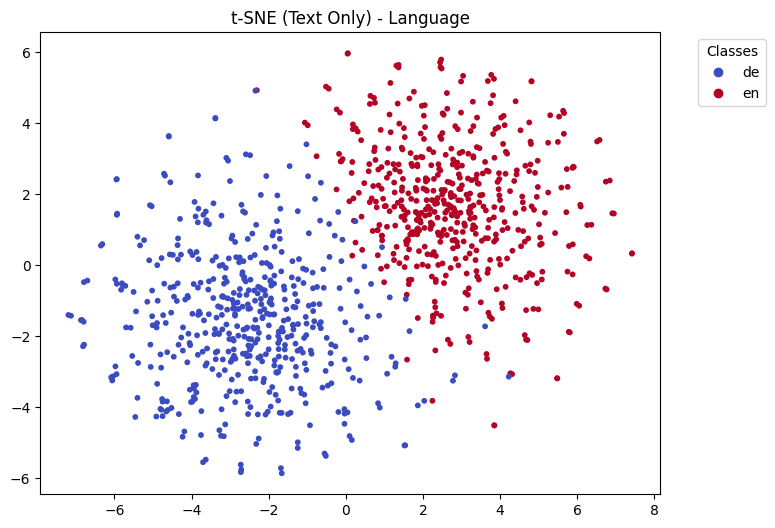

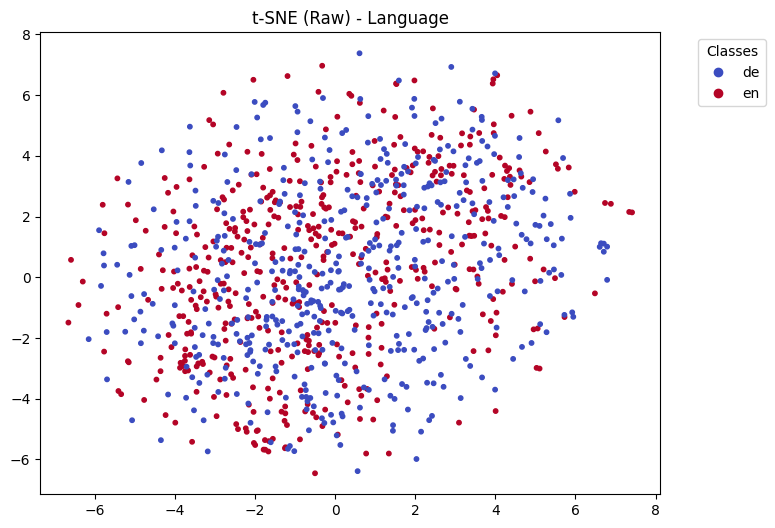

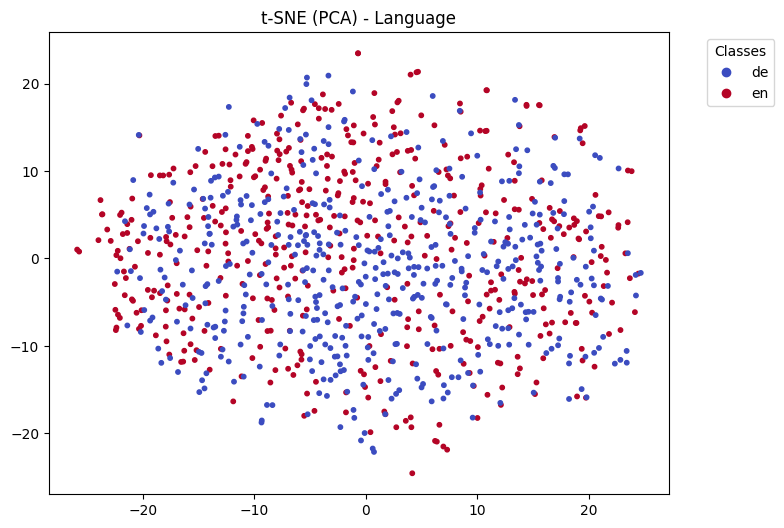

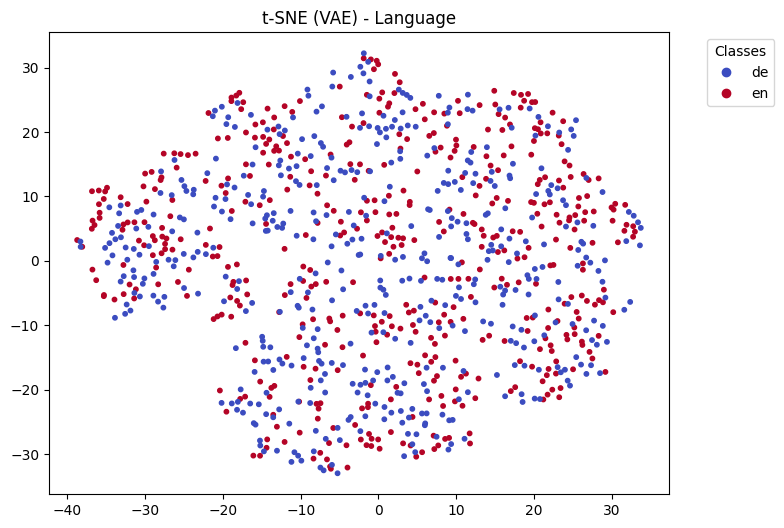

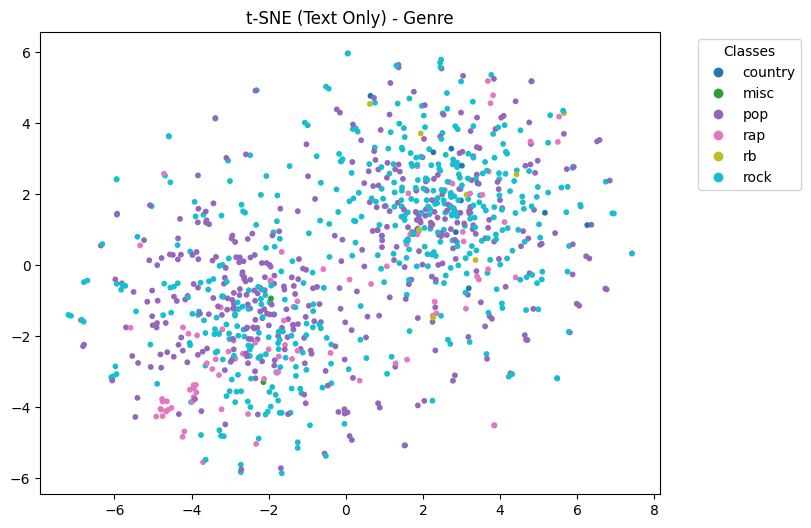

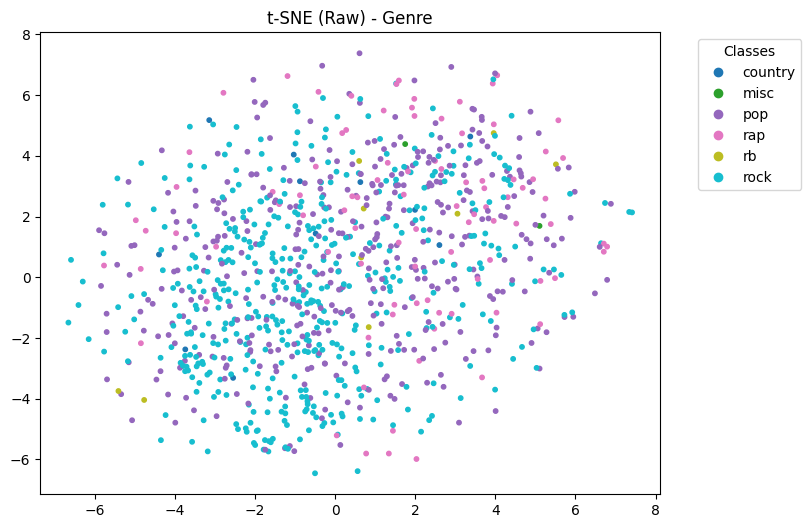

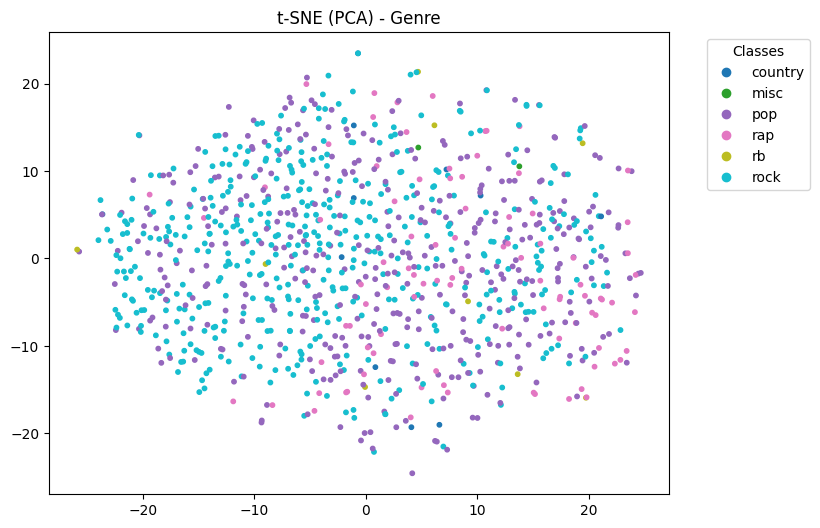

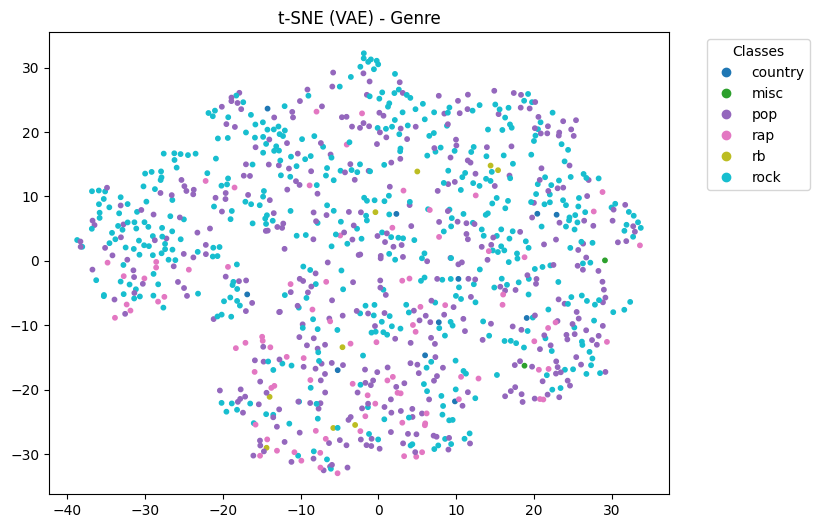

In [10]:
plot_tsne(lyrics_X, languages, 't-SNE (Text Only) - Language', 'results_medium/plots/tsne_language_text.svg', cmap_name='coolwarm')
plot_tsne(Z_raw_combined, languages, 't-SNE (Raw) - Language', 'results_medium/plots/tsne_language_raw.svg', cmap_name='coolwarm')
plot_tsne(Z_pca_combined, languages, 't-SNE (PCA) - Language', 'results_medium/plots/tsne_language_pca.svg', cmap_name='coolwarm')
plot_tsne(Z, languages, 't-SNE (VAE) - Language', 'results_medium/plots/tsne_language_vae.svg', cmap_name='coolwarm')

plot_tsne(lyrics_X, genres, 't-SNE (Text Only) - Genre', 'results_medium/plots/tsne_genre_text.svg', cmap_name='tab10')
plot_tsne(Z_raw_combined, genres, 't-SNE (Raw) - Genre', 'results_medium/plots/tsne_genre_raw.svg', cmap_name='tab10')
plot_tsne(Z_pca_combined, genres, 't-SNE (PCA) - Genre', 'results_medium/plots/tsne_genre_pca.svg', cmap_name='tab10')
plot_tsne(Z, genres, 't-SNE (VAE) - Genre', 'results_medium/plots/tsne_genre_vae.svg', cmap_name='tab10')